# Olist CLV-ML - Modeling

## Objective
Train and compare four regression models to predict customer LTV.
All predictions are made in log scale and converted back to BRL with `np.expm1()`.

**Models:**
1. Linear Regression (baseline)
2. Decision Tree Regressor
3. Random Forest Regressor
4. XGBoost Regressor (main model)

**Metrics:** MAE, RMSE, R²

## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, TargetEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Data Preprocessing

In [4]:
df = pd.read_csv('../data/clean/features.csv')

# Log transforms
df['log_ltv'] = np.log1p(df['total_ltv'])
df['log_monetary'] = np.log1p(df['monetary'])

# Drop columns
df = df.drop(columns=['customer_unique_id', 'max_review_score', 'total_ltv', 'monetary', 'log_monetary'])

# Split
X = df.drop(columns=['log_ltv'])
y = df['log_ltv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imputation
median_review = X_train['avg_review_score'].median()
X_train['avg_review_score'] = X_train['avg_review_score'].fillna(median_review)
X_test['avg_review_score'] = X_test['avg_review_score'].fillna(median_review)

# Impute payment_installments with median
median_installments = X_train['payment_installments'].median()
X_train['payment_installments'] = X_train['payment_installments'].fillna(median_installments)
X_test['payment_installments'] = X_test['payment_installments'].fillna(median_installments)

# Scaling
scaler = StandardScaler()
features_to_scale = ['days_since_first_purchase', 'frequency', 'avg_review_score', 'payment_installments']
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

# Target Encoding
te = TargetEncoder(random_state=42)
X_train['product_category_encoded'] = te.fit_transform(X_train[['product_category_name_english']], y_train)
X_test['product_category_encoded'] = te.transform(X_test[['product_category_name_english']])
X_train = X_train.drop(columns=['product_category_name_english'])
X_test = X_test.drop(columns=['product_category_name_english'])

# One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
payment_train = ohe.fit_transform(X_train[['payment_type']])
payment_test = ohe.transform(X_test[['payment_type']])
payment_cols = ohe.get_feature_names_out(['payment_type'])
X_train = X_train.drop(columns=['payment_type'])
X_test = X_test.drop(columns=['payment_type'])
X_train = pd.concat([X_train, pd.DataFrame(payment_train, columns=payment_cols, index=X_train.index)], axis=1)
X_test = pd.concat([X_test, pd.DataFrame(payment_test, columns=payment_cols, index=X_test.index)], axis=1)
if 'payment_type_nan' in X_train.columns:
    X_train = X_train.drop(columns=['payment_type_nan'])
    X_test = X_test.drop(columns=['payment_type_nan'])

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Features: {X_train.columns.tolist()}")

X_train: (74686, 9)
X_test:  (18672, 9)
Features: ['days_since_first_purchase', 'frequency', 'avg_review_score', 'payment_installments', 'product_category_encoded', 'payment_type_boleto', 'payment_type_credit_card', 'payment_type_debit_card', 'payment_type_voucher']


## 3. Evaluation Function

In [5]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Convert from log scale to BRL
    mae_brl = np.expm1(mae)
    
    print(f"=== {name} ===")
    print(f"MAE:  {mae:.4f} (log) | BRL {mae_brl:.2f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    print()
    
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAE_BRL': mae_brl}

## 4. Models

### 4.1 Linear Regression (Baseline)

In [6]:
results = []

lr_result = evaluate_model(
    "Linear Regression",
    LinearRegression(),
    X_train, X_test, y_train, y_test
)
results.append(lr_result)

=== Linear Regression ===
MAE:  0.6287 (log) | BRL 0.88
RMSE: 0.7975
R²:   0.2795



### 4.2 Decision Tree Regressor

In [7]:
dt_result = evaluate_model(
    "Decision Tree",
    DecisionTreeRegressor(random_state=42),
    X_train, X_test, y_train, y_test
)
results.append(dt_result)

=== Decision Tree ===
MAE:  0.8583 (log) | BRL 1.36
RMSE: 1.1166
R²:   -0.4123



### 4.3 Random Forest Regressor

In [8]:
rf_result = evaluate_model(
    "Random Forest",
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test
)
results.append(rf_result)

=== Random Forest ===
MAE:  0.6661 (log) | BRL 0.95
RMSE: 0.8582
R²:   0.1657



### 4.4 XGBoost Regressor

In [9]:
xgb_result = evaluate_model(
    "XGBoost",
    XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    X_train, X_test, y_train, y_test
)
results.append(xgb_result)

=== XGBoost ===
MAE:  0.6157 (log) | BRL 0.85
RMSE: 0.7906
R²:   0.2920



## 5. Model Comparison

=== Model Comparison ===

            model      MAE     RMSE        R2  MAE_BRL
          XGBoost 0.615709 0.790562  0.292003 0.850968
Linear Regression 0.628748 0.797521  0.279483 0.875261
    Random Forest 0.666134 0.858203  0.165665 0.946697
    Decision Tree 0.858289 1.116582 -0.412346 1.359122


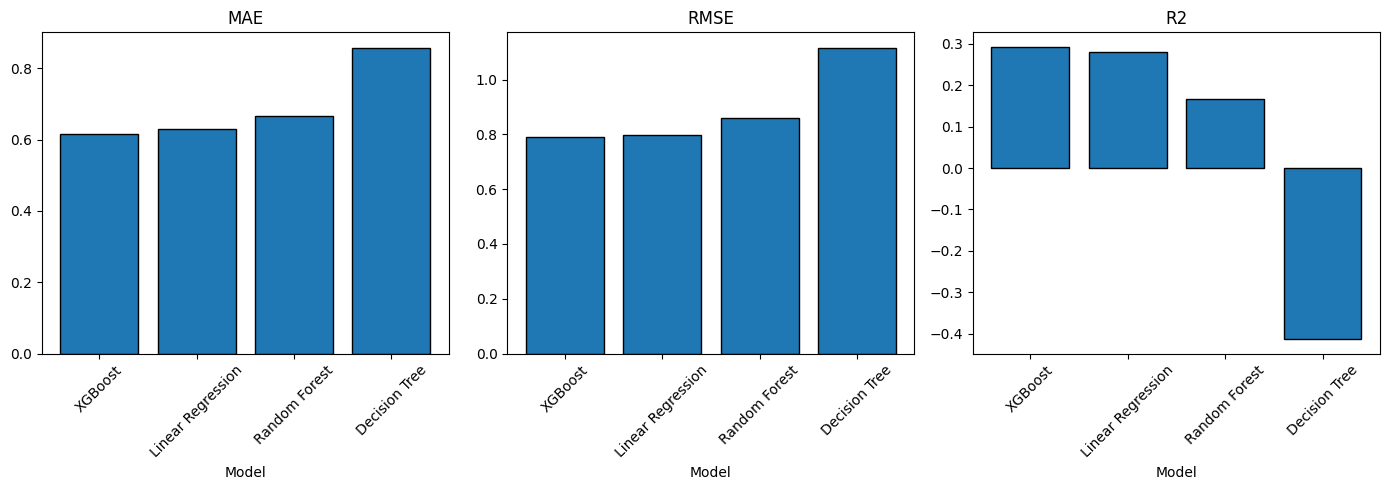

In [10]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

print("=== Model Comparison ===\n")
print(results_df[['model', 'MAE', 'RMSE', 'R2', 'MAE_BRL']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['MAE', 'RMSE', 'R2']
for i, metric in enumerate(metrics):
    axes[i].bar(results_df['model'], results_df[metric], edgecolor='black')
    axes[i].set_title(metric)
    axes[i].set_xlabel('Model')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Results Analysis

XGBoost performs best across all metrics but with minimal advantage over Linear Regression.
This suggests the remaining features have mostly linear relationships with log_ltv.

| Model | R² | Interpretation |
|---|---|---|
| XGBoost | 0.29 | Best model, captures non-linear patterns |
| Linear Regression | 0.28 | Strong baseline, nearly matches XGBoost |
| Random Forest | 0.17 | Reduces overfitting but limited predictive power |
| Decision Tree | -0.41 | Severe overfitting without pruning |

**Overall R² of ~0.29** is expected given that `log_monetary` was removed to avoid 
data leakage. The remaining behavioral features (category, payment method, installments, 
frequency, recency) have real but limited signal.

**Next step:** GridSearchCV on XGBoost to optimize hyperparameters and maximize performance.

## 7. Hyperparameter Tuning — XGBoost + GridSearchCV

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
}

print(f"Total combinations to test: {2 * 3 * 3}")
print(f"With 5-fold CV: {2 * 3 * 3 * 5} fits")
print("\nThis may take a few minutes...")

Total combinations to test: 18
With 5-fold CV: 90 fits

This may take a few minutes...


In [12]:
xgb = XGBRegressor(random_state=42, verbosity=0)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
Best CV R²: 0.3094


In [13]:
xgb_tuned_result = evaluate_model(
    "XGBoost Tuned",
    XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    ),
    X_train, X_test, y_train, y_test
)
results.append(xgb_tuned_result)

=== XGBoost Tuned ===
MAE:  0.6122 (log) | BRL 0.84
RMSE: 0.7857
R²:   0.3006



=== Final Model Comparison ===

            model      MAE     RMSE        R2  MAE_BRL
    XGBoost Tuned 0.612201 0.785719  0.300649 0.844487
          XGBoost 0.615709 0.790562  0.292003 0.850968
Linear Regression 0.628748 0.797521  0.279483 0.875261
    Random Forest 0.666134 0.858203  0.165665 0.946697
    Decision Tree 0.858289 1.116582 -0.412346 1.359122


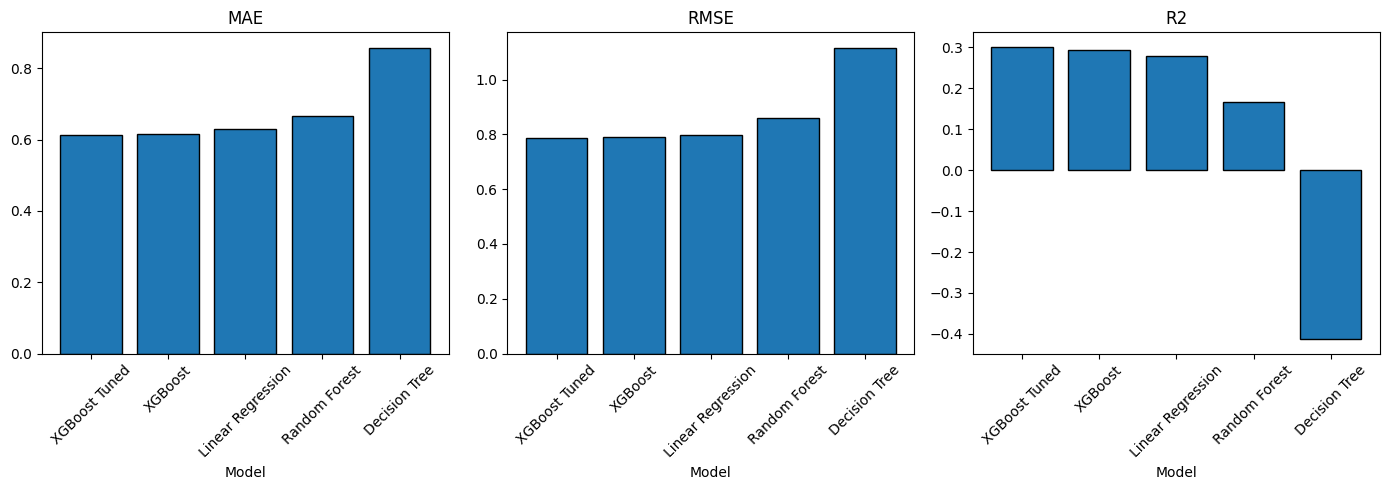

In [14]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

print("=== Final Model Comparison ===\n")
print(results_df[['model', 'MAE', 'RMSE', 'R2', 'MAE_BRL']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['MAE', 'RMSE', 'R2']
for i, metric in enumerate(metrics):
    axes[i].bar(results_df['model'], results_df[metric], edgecolor='black')
    axes[i].set_title(metric)
    axes[i].set_xlabel('Model')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Feature Importance

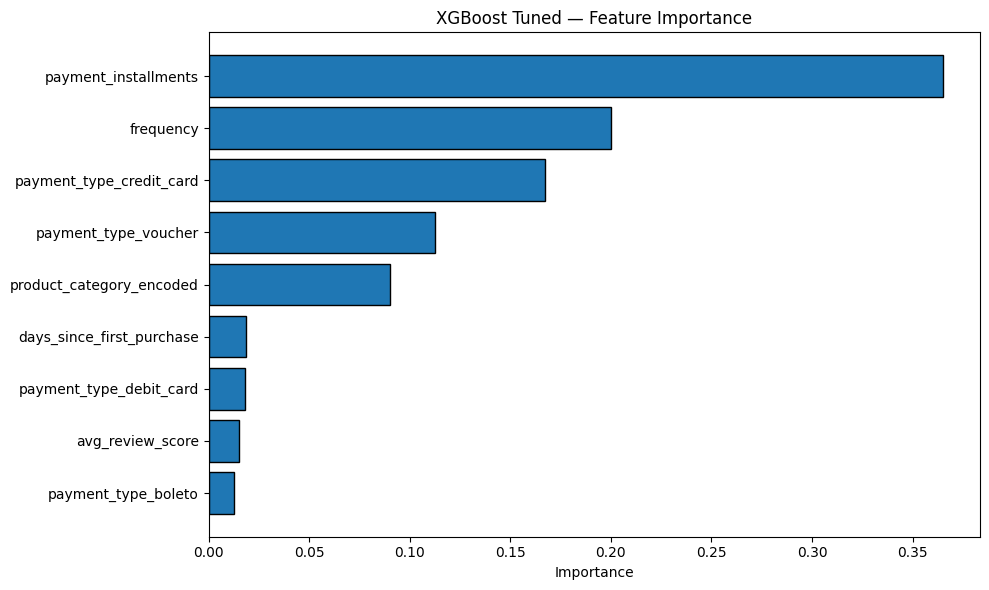

                  feature  importance
     payment_installments    0.365218
                frequency    0.199969
 payment_type_credit_card    0.167325
     payment_type_voucher    0.112701
 product_category_encoded    0.090395
days_since_first_purchase    0.018353
  payment_type_debit_card    0.018221
         avg_review_score    0.015208
      payment_type_boleto    0.012610


In [15]:
best_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
best_model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], edgecolor='black')
plt.title('XGBoost Tuned — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importance_df.sort_values('importance', ascending=False).to_string(index=False))

## 9. Feature Importance Analysis

| Feature | Importance | Interpretation |
|---|---|---|
| payment_installments | 36.5% | Strongest predictor — more installments = higher ticket = higher LTV |
| frequency | 20.0% | Customers who purchased more than once have higher LTV |
| payment_type_credit_card | 16.7% | Credit card users tend to have higher LTV |
| payment_type_voucher | 11.3% | Voucher users have highest average LTV (corporate/promotional) |
| product_category_encoded | 9.0% | Category signal captured via Target Encoding |
| days_since_first_purchase | 1.8% | Low predictive power — recency doesn't predict LTV |
| avg_review_score | 1.5% | Satisfaction has minimal predictive power |

**Key finding:** The enriched features (`payment_installments`, `payment_type`) 
dominate the model, confirming that removing `log_monetary` forced the model 
to learn from genuine behavioral signals of the first purchase.

**Comparison with initial EDA correlation:**
- `avg_review_score` had near-zero correlation with LTV → confirmed low importance (1.5%)
- `days_since_first_purchase` had near-zero correlation → confirmed low importance (1.8%)
- `frequency` had 0.11 correlation → moderate importance (20%)